<a href="https://colab.research.google.com/github/PeroronShine/education_fefu_2/blob/main/Data%20Analytic%20practice/laba1_DataAn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import warnings
warnings.filterwarnings('ignore')
from collections import Counter

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)

In [ ]:
df = pd.read_csv('turkiye-student-evaluation_generic.csv')
df.shape

question_cols = [col for col in df.columns if col.startswith('Q')]

display(df.head())
df.info()

,instr,class,nb.repeat,attendance,difficulty,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28
0,1,2,1,0,4,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
1,1,2,1,1,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
2,1,2,1,2,4,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
3,1,2,1,1,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
4,1,2,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5820 entries, 0 to 5819
Data columns (total 33 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   instr       5820 non-null   int64
 1   class       5820 non-null   int64
 2   nb.repeat   5820 non-null   int64
 3   attendance  5820 non-null   int64
 4   difficulty  5820 non-null   int64
 5   Q1          5820 non-null   int64
 6   Q2          5820 non-null   int64
 7   Q3          5820 non-null   int64
 8   Q4          5820 non-null   int64
 9   Q5          5820 non-null   int64
 10  Q6          5820 non-null   int64
 11  Q7          5820 non-null   int64
 12  Q8          5820 non-null   int64
 13  Q9          5820 non-null   int64
 14  Q10         5820 non-null   int64
 15  Q11         5820 non-null   int64
 16  Q12         5820 non-null   int64
 17  Q13         5820 non-null   int64
 18  Q14         5820 non-null   int64
 19  Q15         5820 non-null   int64
 20  Q16         5820 non-null   in

In [ ]:
duplicates = df.duplicated().sum()
print(f"Количество дубликатов: {duplicates}")

df = df.drop_duplicates()

df.shape # было (5820, 33)

Количество дубликатов: 1843


(3977, 33)

In [ ]:
def detect_straight_lining(df, question_cols, threshold=1.0):
    df_temp = df.copy()
    df_temp['n_unique'] = df_temp[question_cols].apply(lambda x: len(np.unique(x)), axis=1)
    df_temp['std'] = df_temp[question_cols].std(axis=1)

    straight_lining_mask = df_temp['n_unique'] == 1
    return straight_lining_mask, df_temp

def detect_low_variance(df, question_cols, threshold=0.5):
    std_values = df[question_cols].std(axis=1)
    low_variance_mask = std_values < threshold
    return low_variance_mask, std_values

def detect_two_value_pattern(df, question_cols):
    n_unique = df[question_cols].apply(lambda x: len(np.unique(x)), axis=1)
    two_value_mask = n_unique == 2
    return two_value_mask, n_unique

def detect_mechanical_patterns(df, question_cols):
    mechanical_mask = pd.Series([False] * len(df), index=df.index)
    patterns_found = []

    for idx, row in df.iterrows():
        values = row[question_cols].values

        # Проверка на чередование
        if len(values) >= 4:
            is_alternating = True
            for i in range(2, len(values)):
                if values[i] != values[i-2]:
                    is_alternating = False
                    break

            # сравниваем с эл. 2 позиции назад
            if is_alternating and len(np.unique(values)) == 2:
                mechanical_mask[idx] = True
                patterns_found.append({
                    'index': idx,
                    'pattern': 'alternating',
                    'values': np.unique(values).tolist()
                })

    return mechanical_mask, patterns_found

def calculate_quality_score(df, question_cols):
    answers = df[question_cols].values
    std = np.std(answers, axis=1, ddof=1)
    n_unique = np.apply_along_axis(lambda x: len(np.unique(x)), 1, answers)

    score_std = np.clip(std / 1.5 * 100, 0, 100)
    score_unique = (n_unique - 1) / 27 * 100
    quality_score = 0.5 * score_unique + 0.5 * score_std

    return quality_score, None

In [ ]:
straight_mask, df_temp = detect_straight_lining(df, question_cols)
low_var_mask, std_values = detect_low_variance(df, question_cols)
two_val_mask, n_unique = detect_two_value_pattern(df, question_cols)
mech_mask, _ = detect_mechanical_patterns(df, question_cols)
quality_score, _ = calculate_quality_score(df, question_cols)

print(f"Все ответы одинаковые: {straight_mask.sum()} ({straight_mask.mean()*100:.1f}%)")
print(f"Низкая вариативность: {low_var_mask.sum()} ({low_var_mask.mean()*100:.1f}%)")
print(f"1-2 различных ответа: {two_val_mask.sum()} ({two_val_mask.mean()*100:.1f}%)")
print(f"Чередование: {mech_mask.sum()} ({mech_mask.mean()*100:.1f}%)")
print(f"Средний quality_score: {quality_score.mean():.1f}")

quality_scores, df_quality = calculate_quality_score(df, question_cols)
df_clean = df[~(straight_mask | low_var_mask | mech_mask) & (quality_score > 30)]
print(f"\nОсталось записей: {len(df_clean)} из {len(df)} ({len(df_clean)/len(df)*100:.1f}%)")

Все ответы одинаковые: 1155 (29.0%)
Низкая вариативность: 1913 (48.1%)
1-2 различных ответа: 860 (21.6%)
Чередование: 2 (0.1%)
Средний quality_score: 20.1

Осталось записей: 1204 из 3977 (30.3%)


In [ ]:
df[straight_mask].head()

,instr,class,nb.repeat,attendance,difficulty,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28
0,1,2,1,0,4,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
1,1,2,1,1,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3,3
2,1,2,1,2,4,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
4,1,2,1,0,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
5,1,2,1,3,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4


In [ ]:
df[two_val_mask].head()

,instr,class,nb.repeat,attendance,difficulty,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28
8,1,2,1,1,3,4,4,4,4,4,4,4,4,4,4,5,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4
15,1,2,1,3,4,5,5,4,4,5,5,4,4,5,5,5,4,5,5,4,4,5,5,5,4,4,5,5,4,4,4,5,4
25,1,2,1,0,2,1,1,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2,2
26,1,2,1,1,2,1,1,1,1,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
29,1,2,1,3,3,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,4,3,3,3,3,3,3,3


In [ ]:
df[mech_mask].head()

,instr,class,nb.repeat,attendance,difficulty,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28
980,2,1,2,1,3,4,3,4,3,4,3,4,3,4,3,4,3,4,3,4,3,4,3,4,3,4,3,4,3,4,3,4,3
3506,3,5,1,4,1,5,4,5,4,5,4,5,4,5,4,5,4,5,4,5,4,5,4,5,4,5,4,5,4,5,4,5,4


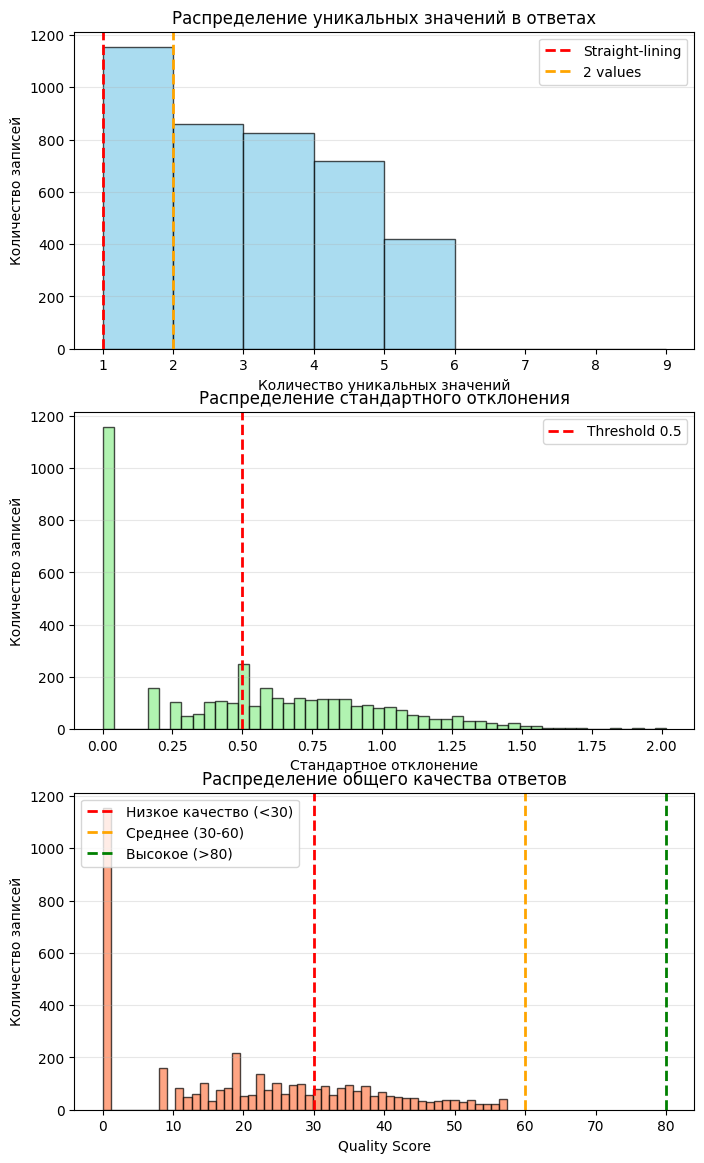

In [ ]:
fig, axes = plt.subplots(3, 1, figsize=(8, 14))

axes[0].hist(df_temp['n_unique'], bins=range(1, 10), edgecolor='black', alpha=0.7, color='skyblue')
axes[0].axvline(x=1, color='red', linestyle='--', linewidth=2, label='Straight-lining')
axes[0].axvline(x=2, color='orange', linestyle='--', linewidth=2, label='2 values')
axes[0].set_xlabel('Количество уникальных значений')
axes[0].set_ylabel('Количество записей')
axes[0].set_title('Распределение уникальных значений в ответах')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

axes[1].hist(std_values, bins=50, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1].axvline(x=0.5, color='red', linestyle='--', linewidth=2, label='Threshold 0.5')
axes[1].set_xlabel('Стандартное отклонение')
axes[1].set_ylabel('Количество записей')
axes[1].set_title('Распределение стандартного отклонения')
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)

axes[2].hist(quality_scores, bins=50, edgecolor='black', alpha=0.7, color='coral')
axes[2].axvline(x=30, color='red', linestyle='--', linewidth=2, label='Низкое качество (<30)')
axes[2].axvline(x=60, color='orange', linestyle='--', linewidth=2, label='Среднее (30-60)')
axes[2].axvline(x=80, color='green', linestyle='--', linewidth=2, label='Высокое (>80)')
axes[2].set_xlabel('Quality Score')
axes[2].set_ylabel('Количество записей')
axes[2].set_title('Распределение общего качества ответов')
axes[2].legend()
axes[2].grid(axis='y', alpha=0.3)

In [ ]:
pct_straight = straight_mask.sum() / len(df) * 100

pct_low_var = low_var_mask.sum() / len(df) * 100

pct_two_val = two_val_mask.sum() / len(df) * 100

pct_mech =  mech_mask.sum() / len(df) * 100

In [ ]:
comparison_data = {
    '       ': ['Всего записей', 'Straight-lining', 'Low variance',
                'Two-value', 'Mechanical', 'Средний quality score'],
    'До очистки': [
        len(df),
        f"{straight_mask.sum()} ({pct_straight:.1f}%)",
        f"{low_var_mask.sum()} ({pct_low_var:.1f}%)",
        f"{two_val_mask.sum()} ({pct_two_val:.1f}%)",
        f"{mech_mask.sum()} ({pct_mech:.1f}%)",
        f"{quality_scores.mean():.1f}"
    ],
    'После очистки': [
        len(df_clean),
        f"{detect_straight_lining(df_clean, question_cols)[0].sum()}",
        f"{detect_low_variance(df_clean, question_cols, 0.5)[0].sum()}",
        f"{detect_two_value_pattern(df_clean, question_cols)[0].sum()}",
        f"{detect_mechanical_patterns(df_clean, question_cols)[0].sum()}",
        f"{calculate_quality_score(df_clean, question_cols)[0].mean():.1f}"
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print(comparison_df.to_string(index=False))

df_clean.to_csv('turkiye_student_evaluation_CLEANED.csv', index=False)

                        До очистки После очистки
        Всего записей         3977          1204
      Straight-lining 1155 (29.0%)             0
         Low variance 1913 (48.1%)             0
            Two-value  860 (21.6%)            53
           Mechanical     2 (0.1%)             0
Средний quality score         20.1          40.6


In [ ]:
df_clean.head(15)

,instr,class,nb.repeat,attendance,difficulty,Q1,Q2,Q3,Q4,Q5,Q6,Q7,Q8,Q9,Q10,Q11,Q12,Q13,Q14,Q15,Q16,Q17,Q18,Q19,Q20,Q21,Q22,Q23,Q24,Q25,Q26,Q27,Q28
23,1,2,1,2,4,5,3,3,3,2,2,3,3,3,4,4,5,5,4,3,3,3,4,2,2,4,4,5,5,4,4,5,5
26,1,2,1,1,2,1,1,1,1,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5,5
42,1,2,2,1,3,2,3,3,3,2,5,5,5,5,5,5,5,3,3,3,3,3,3,3,3,3,3,3,2,2,1,1,1
45,1,2,1,3,4,2,3,4,5,5,4,4,4,5,4,4,4,4,4,4,4,4,2,2,2,4,2,2,4,2,2,3,2
48,1,2,1,1,3,4,4,4,3,4,2,4,5,3,3,4,1,5,5,5,5,5,5,5,5,5,5,3,4,5,4,4,5
55,1,2,1,1,1,1,1,1,1,1,1,1,5,1,1,1,5,5,5,5,5,5,4,5,5,5,5,5,5,5,4,5,5
61,1,2,1,3,3,2,4,4,2,5,5,5,5,4,4,5,4,5,5,5,5,5,5,5,5,5,5,5,5,5,5,4,5
71,1,2,1,0,1,3,3,1,3,1,2,2,2,2,1,1,1,3,4,4,3,2,4,1,3,3,3,2,3,4,2,3,3
73,1,2,1,1,5,5,2,2,2,5,5,5,5,5,5,5,5,5,5,5,5,4,5,5,5,5,5,5,4,5,5,1,5
93,1,2,3,1,1,1,1,1,1,5,3,2,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
